In [1]:
# imdb dataset을 이용해서 감성분류를 해보아요
# 영어로 되어 있는 리뷰를 토큰으로 분리
# vocabulary를 생성한 후 이를 이용해서 리뷰를 숫자의 시퀸스로 변경
# label로는 각 리뷰가 긍정의 리뷰면 1, 부정의 리뷰면 0으로 제공

In [3]:
from tensorflow.keras.datasets import imdb

(x_data_train, y_data_train), (x_data_test, y_data_test)=imdb.load_data(num_words=500)
# num_word는 내가 사용할 vocabulary안의 단어수, 빈도수가 높은 단어 500개를 사용하겠다는 의미


In [4]:
print(x_data_train.shape) #(25000,)
print(x_data_test.shape)  #(25000,)
print(y_data_train.shape) #(25000,)
print(y_data_train[:5]) #[1 0 0 1 0]
print(x_data_train[0]) #python의 list -> 리뷰1개당
# [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 22665, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 21631, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 19193, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 10311, 8, 4, 107, 117, 5952, 15, 256, 4, 31050, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 12118, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
print(y_data_test.shape)  #(25000,)

(25000,)
(25000,)
(25000,)
[1 0 0 1 0]
[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 458, 2, 66, 2, 4, 173, 36, 256, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 2, 2, 17, 2, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 469, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2, 2, 16, 480, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 476, 26, 400, 317, 46, 7, 4, 2, 2, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 2, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 2, 88, 12, 16, 283, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]
(25000,)


In [5]:
# 그러면 각각의 리뷰의 길이를 알아보아요
print(len(x_data_train[0])) #218 218개의 토큰으로 구성되어있다
print(len(x_data_train[1])) #189
print(len(x_data_train[2])) #141

218
189
141


In [6]:
# 이런 리뷰 데이터를 모델안에 집어넣어서 연산을 수행하려면 데이터의 길이가(shape)이 같아야되요
# 각 리뷰마다 길이가 다른데 어떻게 리뷰의 길이를 똑같이 만드나요?
# 가장 길이가 긴 리뷰의 길이로 전체 리뷰들의 길이를 늘려요! -> 가능은 하지만 사이즈만 커지지 공간의 낭비다 (안좋은 방법)
# 적절한 길이로 전체 리뷰들의 길이를 제한 -> CNN에서 이미지 크기 고정시키듯이
# -> 어떤 리뷰들은 조금 짤릴거구요, 어떤 리뷰들은 길이가 늘어날거에요!
# 사실 모델 구현하는건 대부분 똑같다. 그니까 데이터 핸들링이 중요하다!(특히 한글은 형태소 분리가 있어서)

[218 189 141 550 147  43 123 562 233 130]
238.71364
178.0


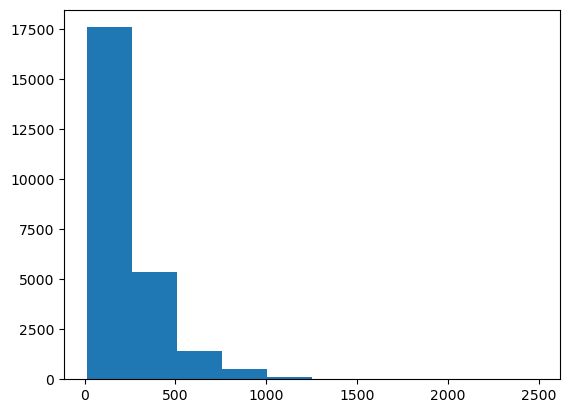

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 각 리뷰에 대한 길이를 구해서 ndarray에 저장
lengths = np.array([len(x) for x in x_data_train])
print(lengths[:10]) # [218 189 141 550 147  43 123 562 233 130]
print(np.mean(lengths)) # 리뷰의 평균값 238.71364
print(np.median(lengths)) # 리뷰의 중앙값 178.0

plt.hist(lengths)  # 빈도수에 따라 적절하게 그려줄거다
plt.show()

In [8]:
# 평균, 중앙값, 히스토그램을 구해봤더니 대략 100~150개의 토큰으로 이루어진 리뷰들이 많다는걸 확인할 수 있었어요
# 그래서 토큰 100개로 모든 리뷰의 길이를 조절

from tensorflow.keras.preprocessing.sequence import pad_sequences
x_data_train_seq = pad_sequences(x_data_train,
                               maxlen=100)
# 모든 리뷰에 대한 길이가 토큰 100개 짜리로 맞춰지게 되요
print(x_data_train_seq.shape) # (25000, 100)

(25000, 100)


In [9]:
# 기본적으로 padding처리는 짧은 길이는 앞쪽에 0(padding)을 추가
# 길이가 긴 리뷰(길이가 긴 데이터)는 앞쪽 데이터를 짤라요

In [10]:
# 데이터가 준비되었으니 이제 모델을 구성해 보아요
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

model = Sequential()
model.add(SimpleRNN(units=8,
                   activation='tanh',
                   input_shape=(100,500)))
model.add(Dense(units=1,
               activation='sigmoid'))

2025-07-07 12:11:32.248208: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-07-07 12:11:32.381394: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-07-07 12:11:32.381448: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-07-07 12:11:32.386210: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-07-07 12:11:32.386270: I external/local_xla/xla/stream_executor

In [11]:
print(x_data_train_seq[0])
# 어떻게 하면 각 토큰에 대한 값들이 볼륨(크기)을 가지지 않고 특정 category를 표현하도록 할 수 있을까요? => one-hot-encoding
# one-hot으로 바꾸면 카테고리의 개수는 500개

[  2  33   6  22  12 215  28  77  52   5  14 407  16  82   2   8   4 107
 117   2  15 256   4   2   7   2   5   2  36  71  43   2 476  26 400 317
  46   7   4   2   2  13 104  88   4 381  15 297  98  32   2  56  26 141
   6 194   2  18   4 226  22  21 134 476  26 480   5 144  30   2  18  51
  36  28 224  92  25 104   4 226  65  16  38   2  88  12  16 283   5  16
   2 113 103  32  15  16   2  19 178  32]


In [12]:
# 입력값으로 토큰에 대한 원핫 인코딩값을 사용해야 되기 때문애 
# 원핫 인코딩으로 각 리뷰가 가지는 토큰들을 변환
from tensorflow.keras.utils import to_categorical

x_data_train_onehot = to_categorical(x_data_train_seq,
                                    num_classes=500)
print(x_data_train_onehot.shape) # (25000, 100, 500)
# (sample의 개수, token의 개수 = timestep, feature -> 토큰을 표현하는 데이터값)
# 원핫인코딩 방법은 공간의 낭비가 생겨요. 메모리를 많이 사용하게됨.

(25000, 100, 500)


In [9]:
%reset -f

In [10]:
import numpy as np
import tensorflow as tf
import datetime
from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Lambda
# 메모리 부족으로 학습이 안됨 커널 죽음
# 그래서 이때 꼼수로 학습을 할 수 있는 방법이 있어요 Lambda 람다를 통과할때만 원핫인코딩을 하겠다는 레이어임. 한번에 원핫해서 메모리 부족이 뜬거니까
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import TensorBoard

In [11]:
# data loading

(x_data_train, y_data_train), (x_data_test, y_data_test) = imdb.load_data(num_words=500)
x_data_train, x_data_val, y_data_train, y_data_val = train_test_split(x_data_train,
                                                                     y_data_train,
                                                                     test_size=0.2,
                                                                     stratify=y_data_train)

In [12]:
# padding 처리 -> 길이를 100으로 변경
x_data_train_seq = pad_sequences(x_data_train,
                                maxlen=100)
x_data_val_seq = pad_sequences(x_data_val,
                                maxlen=100)

# Lambda를 사용하면 이땐 이거 주석으로 사용 안함
# 이 형태의 구현은 메모리 부족을 야기시킬 수 있어요. 실제로 현업에서는 사용하지않음.
# # one-hot처리 -> class 개수는 500개
# x_data_train_onehot = to_categorical(x_data_train_seq,
#                                     num_classes=500)
# x_data_val_onehot = to_categorical(x_data_val_seq,
#                                     num_classes=500)

# model
model = Sequential()
model.add(Lambda(lambda x:tf.one_hot(tf.cast(x, tf.int32),500),
                input_shape=(100,)))
model.add(SimpleRNN(units=8,
                   activation='tanh'))
                   # input_shape=(100,500)))
model.add(Dense(units=1,
               activation='sigmoid'))
model.compile(optimizer=Adam(learning_rate=1e-3),
             loss='binary_crossentropy',
             metrics=['accuracy'])
es_cb = EarlyStopping(monitor='val_loss',
                     patience=5,
                     restore_best_weights=True,
                     verbose=1)
cp_cb = ModelCheckpoint(filepath='./simpleRNN-model.weights.h5',
                        monitor='val_loss',
                        save_best_only=True,
                        save_weights_only=True,
                        verbose=1)
log_dir = './logs/'+datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
tb_cb = TensorBoard(log_dir=log_dir,
                   histogram_freq=1)

/home/govlept1004/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
# 학습을 진행해 보아요
# tensorflow 2.16, CUDA 12.3에서는 오류! 메모리 오류
# tensorflow 2.13, CUDA 11.8에서는 동작

model.fit(x_data_train_seq,
         y_data_train,
         epochs=100,
         batch_size=64,
         validation_data=(x_data_val_seq, y_data_val),
         callbacks=[es_cb,cp_cb,tb_cb],
         verbose=1)

Epoch 1/100


I0000 00:00:1751861741.402132    1932 service.cc:145] XLA service 0x7f6458015c70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1751861741.402188    1932 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Ti Laptop GPU, Compute Capability 8.6
2025-07-07 13:15:41.437022: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-07-07 13:15:41.565533: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8900


  1/313 ━━━━━━━━━━━━━━━━━━━━ 7:01 1s/step - accuracy: 0.5469 - loss: 0.6843

I0000 00:00:1751861741.983640    1932 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5101 - loss: 0.6969 
Epoch 1: val_loss improved from inf to 0.68779, saving model to ./simpleRNN-model.weights.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.5101 - loss: 0.6968 - val_accuracy: 0.5412 - val_loss: 0.6878
Epoch 2/100
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5757 - loss: 0.6792
Epoch 2: val_loss improved from 0.68779 to 0.68185, saving model to ./simpleRNN-model.weights.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5757 - loss: 0.6792 - val_accuracy: 0.5582 - val_loss: 0.6818
Epoch 3/100
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6091 - loss: 0.6628
Epoch 3: val_loss improved from 0.68185 to 0.67831, saving model to ./simpleRNN-model.weights.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6091 - loss: 0.6628 - val_accuracy: 0.5572 - val_loss: 0.6783
Epoch 4/100
310/313 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6374 - loss: 0.6408
Epoch 4: val_loss 

In [14]:
x_data_test_seq = pad_sequences(x_data_test,
                               maxlen=100)

result = model.evaluate(x_data_test_seq, y_data_test)
print(result)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5737 - loss: 0.6755  
[0.6758687496185303, 0.5687999725341797]


In [ ]:
# 학습을 진행해 보아요
# tensorflow 2.16, CUDA 12.3에서는 오류! 메모리 오류
# tensorflow 2.13, CUDA 11.8에서는 동작

model.fit(x_data_train_onehot,
         y_data_train,
         epochs=100,
         batch_size=64,
         validation_data=(x_data_val_onehot, y_data_val),
         callbacks=[es_cb,cp_cb,tb_cb],
         verbose=1)

# 메모리 부족으로 학습이 안됨 커널 죽음
# 그래서 이때 꼼수로 학습을 할 수 있는 방법이 있어요